# Hemoglobin EDA
This notebook continues our EDA of *kidney_disease_random_1000_patients.csv.gz* and *normal_kidney_patients.csv.gz*. The goal is to compare how ill the 1000 patients with kidney disease are relative to the group of patients with normal kidneys. To accomplish this goal, the patients will be divided into groups according to hemoglobin (`itemid` = 50811) levels. The groups are : $<6$, $6-8$, $8-10$, $10-12$, and $>12$. To form the groups, the value from the first testing of hemoglobin is used. 

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
kidney_disease_df = pd.read_csv('../Data/kidney_disease_random_1000_patients.csv.gz',
                               compression = 'gzip') 
kidney_disease_df.head()

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,917899,10061124,24090860.0,19944894,50868,NaN,2168-08-03 19:30:00,2168-08-03 20:03:00,11,11.0,mEq/L,8.0,20.0,NaN,STAT,NaN
1,917900,10061124,24090860.0,19944894,50882,NaN,2168-08-03 19:30:00,2168-08-03 20:03:00,28,28.0,mEq/L,22.0,32.0,NaN,STAT,NaN
2,917901,10061124,24090860.0,19944894,50902,NaN,2168-08-03 19:30:00,2168-08-03 20:03:00,106,106.0,mEq/L,96.0,108.0,NaN,STAT,NaN
3,917902,10061124,24090860.0,19944894,50912,NaN,2168-08-03 19:30:00,2168-08-03 20:03:00,1.3,1.3,mg/dL,0.5,1.2,abnormal,STAT,NaN
4,917903,10061124,24090860.0,19944894,50920,NaN,2168-08-03 19:30:00,2168-08-03 20:03:00,NaN,NaN,NaN,NaN,NaN,NaN,STAT,"Using this patient's age, gender, and serum cr..."


The next cell first restricts the dataframe for kidney disease patients to those that have a hemoglobin lab reading. Next, the earliest hemoglobin lab reading is extracted for each patient. The result is stored in the dataframe `hemoglobin_labs_kidney_disease`.

In [22]:
hemoglobin_itemid = 50811
hemoglobin_kidney_disease = kidney_disease_df.loc[kidney_disease_df['itemid'] == hemoglobin_itemid]
hemoglobin_kidney_disease_ids = list(set(hemoglobin_kidney_disease['subject_id']))
hemoglobin_labs_kidney_disease = pd.DataFrame(columns = ['hemoglobin'])
for patient in hemoglobin_kidney_disease_ids:
    earliest_lab_date = hemoglobin_kidney_disease.loc[hemoglobin_kidney_disease['subject_id'] == patient, 'charttime'].min()
    hemoglobin_labs_kidney_disease.loc[patient] = hemoglobin_kidney_disease.loc[hemoglobin_kidney_disease['charttime'] == earliest_lab_date, 'valuenum'].values
hemoglobin_labs_kidney_disease.head()

,hemoglobin
16033805,11.6
14870544,13.8
10209298,8.4
11413537,10.4
10694694,14.1


In [23]:
normal_kidney_df = pd.read_csv('../Data/normal_kidney_patients.csv.gz',
                              compression = 'gzip')
normal_kidney_df.head()

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,617746,10039302,25044971.0,12440596,50868,NaN,2118-02-06 00:10:00,2118-02-06 01:28:00,16,16.0,mEq/L,8.0,20.0,NaN,STAT,NaN
1,617747,10039302,25044971.0,12440596,50882,NaN,2118-02-06 00:10:00,2118-02-06 01:28:00,26,26.0,mEq/L,22.0,32.0,NaN,STAT,NaN
2,617748,10039302,25044971.0,12440596,50893,NaN,2118-02-06 00:10:00,2118-02-06 01:28:00,9.6,9.6,mg/dL,8.4,10.2,NaN,STAT,NaN
3,617749,10039302,25044971.0,12440596,50902,NaN,2118-02-06 00:10:00,2118-02-06 01:28:00,106,106.0,mEq/L,96.0,108.0,NaN,STAT,NaN
4,617750,10039302,25044971.0,12440596,50912,NaN,2118-02-06 00:10:00,2118-02-06 01:28:00,1.0,1.0,mg/dL,0.4,1.1,NaN,STAT,NaN


Similar to what was done above for patients with kidney disease, the next cell begins by reducing the dataframe for normal kidney patients to the set of patients that have a hemoglobin lab reading. Once this is accomplished, the earliest lab reading for each patient is extracted and stored in the dataframe `hemoglobin_labs_normal_kidneys`.

In [24]:
hemoglobin_normal_kidney = normal_kidney_df.loc[normal_kidney_df['itemid'] == hemoglobin_itemid]
hemoglobin_normal_kidney_ids = list(set(hemoglobin_normal_kidney['subject_id']))
hemoglobin_labs_normal_kidneys = pd.DataFrame(columns = ['hemoglobin'])
for patient in hemoglobin_normal_kidney_ids:
    earliest_lab_date = hemoglobin_normal_kidney.loc[hemoglobin_normal_kidney['subject_id'] == patient, 'charttime'].min()
    hemoglobin_labs_normal_kidneys.loc[patient] = hemoglobin_normal_kidney.loc[hemoglobin_normal_kidney['charttime'] == earliest_lab_date, 'valuenum'].values
hemoglobin_labs_normal_kidneys.head()

,hemoglobin
10061303,13.3
10039302,11.5
10064390,14.6
10056200,13.0
10014729,12.9


With the necessary data at hand, we now compute the number of patients from each of the two groups (i.e. kidney disease and normal kidney) that fall into the categories: $<6$, $6-8$, $8-10$, $10-12$, and $>12$. The result is printed following the next code cell.

In [25]:
kidney_disease_less_than_6 = hemoglobin_labs_kidney_disease.loc[hemoglobin_labs_kidney_disease['hemoglobin'] < 6].shape[0]
kidney_disease_6_to_8 = hemoglobin_labs_kidney_disease.loc[(hemoglobin_labs_kidney_disease['hemoglobin'] >= 6) & (hemoglobin_labs_kidney_disease['hemoglobin'] < 8)].shape[0]
kidney_disease_8_to_10 = hemoglobin_labs_kidney_disease.loc[(hemoglobin_labs_kidney_disease['hemoglobin'] >= 8) & (hemoglobin_labs_kidney_disease['hemoglobin'] < 10)].shape[0]
kidney_disease_10_to_12 = hemoglobin_labs_kidney_disease.loc[(hemoglobin_labs_kidney_disease['hemoglobin'] >= 10) & (hemoglobin_labs_kidney_disease['hemoglobin'] < 12)].shape[0]
kidney_disease_more_than_12 = hemoglobin_labs_kidney_disease.loc[hemoglobin_labs_kidney_disease['hemoglobin'] >= 12].shape[0]

normal_kidney_less_than_6 = hemoglobin_labs_normal_kidneys.loc[hemoglobin_labs_normal_kidneys['hemoglobin'] < 6].shape[0]
normal_kidney_6_to_8 = hemoglobin_labs_normal_kidneys.loc[(hemoglobin_labs_normal_kidneys['hemoglobin'] >= 6) & (hemoglobin_labs_normal_kidneys['hemoglobin'] < 8)].shape[0]
normal_kidney_8_to_10 = hemoglobin_labs_normal_kidneys.loc[(hemoglobin_labs_normal_kidneys['hemoglobin'] >= 8) & (hemoglobin_labs_normal_kidneys['hemoglobin'] < 10)].shape[0]
normal_kidney_10_to_12 = hemoglobin_labs_normal_kidneys.loc[(hemoglobin_labs_normal_kidneys['hemoglobin'] >= 10) & (hemoglobin_labs_normal_kidneys['hemoglobin'] < 12)].shape[0]
normal_kidney_more_than_12 = hemoglobin_labs_normal_kidneys.loc[hemoglobin_labs_normal_kidneys['hemoglobin'] >= 12].shape[0]

print('Hemoglobin reading less than 6:', 'kidney disease patients =', kidney_disease_less_than_6, 'and normal kidney patients =', normal_kidney_less_than_6, '\n')
print('Hemoglobin reading between 6 and 8:', 'kidney disease patients =', kidney_disease_6_to_8, 'and normal kidney patients =', normal_kidney_6_to_8, '\n')
print('Hemoglobin reading between 8 and 10:', 'kidney disease patients =', kidney_disease_8_to_10, 'and normal kidney patients =', normal_kidney_8_to_10, '\n')
print('Hemoglobin reading between 10 and 12:', 'kidney disease patients =', kidney_disease_10_to_12, 'and normal kidney patients =', normal_kidney_10_to_12, '\n')
print('Hemoglobin reading greater than 12:', 'kidney disease patients =', kidney_disease_more_than_12, 'and normal kidney patients =', normal_kidney_more_than_12)

Hemoglobin reading less than 6: kidney disease patients = 11 and normal kidney patients = 0 

Hemoglobin reading between 6 and 8: kidney disease patients = 32 and normal kidney patients = 3 

Hemoglobin reading between 8 and 10: kidney disease patients = 100 and normal kidney patients = 17 

Hemoglobin reading between 10 and 12: kidney disease patients = 121 and normal kidney patients = 43 

Hemoglobin reading greater than 12: kidney disease patients = 118 and normal kidney patients = 85


Finally, we visualize the difference between the two groups by creating histograms. Shown in red is the data for patients with kidney disease, while shown in blue is the data for patients with normal kidneys. Notice from the histogram that patients with kidney disease tend to have lower hemoglobin lab readings. 

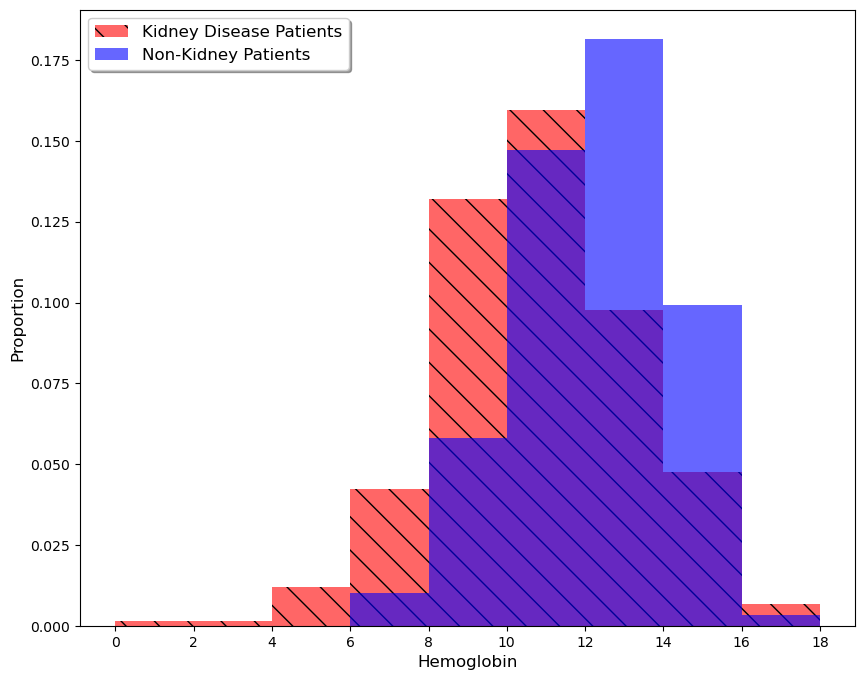

In [30]:
plt.figure(figsize = (10, 8))
plt.hist(hemoglobin_labs_kidney_disease['hemoglobin'],
        color = 'red',
        hatch = '\\',
        bins = np.arange(0, 20, 2),   #(1) <6, (2) 6-8, (3) 8-10, (4) 10-12, (5) >12
        alpha = 0.6,
        density = True,
        label = 'Kidney Disease Patients')
plt.hist(hemoglobin_labs_normal_kidneys['hemoglobin'],
        color = 'blue',
        bins = np.arange(0, 20, 2),
        alpha = 0.6,
        density = True,
        label = 'Non-Kidney Patients')
plt.xticks(np.arange(0, 20, 2))
plt.legend(fontsize = 12,
          loc = 'upper left',
          fancybox = True,
          shadow = True)
plt.ylabel('Proportion',
          fontsize = 12)
plt.xlabel('Hemoglobin',
          fontsize = 12)
plt.savefig('../Assets/hemoglobin_eda.png')
plt.show()